In [10]:
import sys

from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers import Moser2021

In [5]:
importlib.reload(Moser2021)

Moser2021.Table3_bestfit().df

,massselect,colorselect,halo,match,log10p0,alphak,betak,Ak2h,P0,xct,betat,At2h
0,mstar,tot,GNFW,matched,3.67,0.64,3.37,1.40,4.18,0.97,6.09,0.57
1,mstar,red,GNFW,matched,3.28,0.80,3.20,1.37,4.03,1.00,6.14,0.53
2,mh,tot,GNFW,matched,4.34,0.43,3.44,1.31,2.74,0.98,6.31,0.51
3,mh,red,GNFW,matched,3.38,0.68,3.30,1.34,2.86,0.93,5.80,0.51
4,mstar,tot,GNFW,unmatched,4.11,0.49,3.30,1.31,3.95,0.98,5.00,0.49
5,mstar,red,GNFW,unmatched,3.38,0.68,2.91,1.28,4.91,0.98,4.65,0.47
6,mh,tot,GNFW,unmatched,5.68,0.30,3.54,1.20,3.84,0.98,4.61,0.44
7,mh,red,GNFW,unmatched,3.48,0.61,3.03,1.30,4.47,0.95,4.55,0.47
8,mstar,tot,GNFW1h,matched,6.00,0.17,2.06,NaN,18.33,0.06,1.53,NaN
9,mstar,red,GNFW1h,matched,6.00,0.16,1.99,NaN,17.37,0.06,1.54,NaN


In [ ]:
importlib.reload(Moser2021)
fig, axs = Moser2021.Fig2().full()


from Models import HaloModels
from Models.Papers import Battaglia2012
from Models.Papers import Battaglia2016
importlib.reload(HaloModels); importlib.reload(Battaglia2012); importlib.reload(Battaglia2016)

rs, z, logM = np.geomspace(1e-3, 1e2, 50), 0.57, np.log10(2e13)

hmod = HaloModels.pyccl_model(Moser2021.Study().info)
xs = rs*u.Mpc/hmod.rdel('200c')(z, logM)
B11 = Battaglia2012.HaloProfiles(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
B16 = Battaglia2016.HaloProfiles(model='AGN', rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
ptypo = {'beta_A0': B16.p0['beta_A0']-2*B16.p0['gamma']}
axs[0].scatter(xs, B16.Density(rs, z, logM, units='cgs')(ptypo)[:, 0, 0]*2, c='orange', label='B16 x2')
axs[1].scatter(xs, B11.Pressure(rs, z, logM, units='cgs')()[:, 0, 0]*2, c='orange', label='B11 x2')

# hmod2 = HaloModels.pyccl_model(MassDef='fof', MassFunc='sheth99', HaloBias='sheth01', PowSpec='LINEAR')
# dndlogm2 = lambda z, logm: hmod2.dndlogm(z, hmod.logM_conv(z, logm, 'fof')-np.log10(hmod2.params['h']))*hmod2.params['h']**4
# bh2 = lambda z, logm: hmod2.bh(z, logm-np.log10(hmod2.params['h']))
# Plin2 = lambda k, z: hmod2.Plin(k*hmod2.params['h'], z)/hmod2.params['h']**3

# hmod2 = HaloModels.mopc_model()

# Moser2021 = Profiles.Moser2021(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), **Studies.Amodeo2021().info, dndlogm=hmod2.dndlogm, bh=hmod2.bh, Plin=hmod2.Plin)
# axs[0].scatter(xs, Moser2021.dens2h(rs, z, logM, units='cgs')()[:, 0, 0]*2, c='cyan', label='M21 2h x2')
# axs[1].scatter(xs, Moser2021.pres2h(rs, z, logM, units='cgs')()[:, 0, 0]*2*2, c='cyan', label='M21 2h x4')

# axs[0].scatter(xs, Moser2021.dens1h(rs, z, logM, units='cgs')({'logrho0':np.log10(4e3), 'alpha_k':0.88, 'beta_k':3.83})[:, 0, 0], c='magenta', label='1h')
# axs[1].scatter(xs, Moser2021.pres1h(rs, z, logM, units='cgs')()[:, 0, 0], c='magenta', label='1h')

axs[0].legend(title='z=0.57, M=2e13'); axs[1].legend(title='z=0.57, M=2e13')
plt.show()

In [12]:
b_cen = np.array(
    [
        [
            11.31932504,
            11.43785913,
            11.57526319,
            11.74539764,
            11.97016907,
            12.27689266,
            12.67884686,
            13.16053855,
            13.69871423,
        ]
    ]
).T
p = np.array(
    [
        2.94467222e-06,
        2.94467222e-06,
        2.94467222e-06,
        1.47233611e-05,
        3.38637305e-05,
        4.13431979e-03,
        1.31666601e-01,
        3.36540698e-01,
        8.13760167e-02,
    ]
)

b_cen = np.array([[12.27689266, 12.67884686, 13.16053855, 13.69871423]]).T
p = np.array([4.13431979e-03, 1.31666601e-01, 3.36540698e-01, 8.13760167e-02])

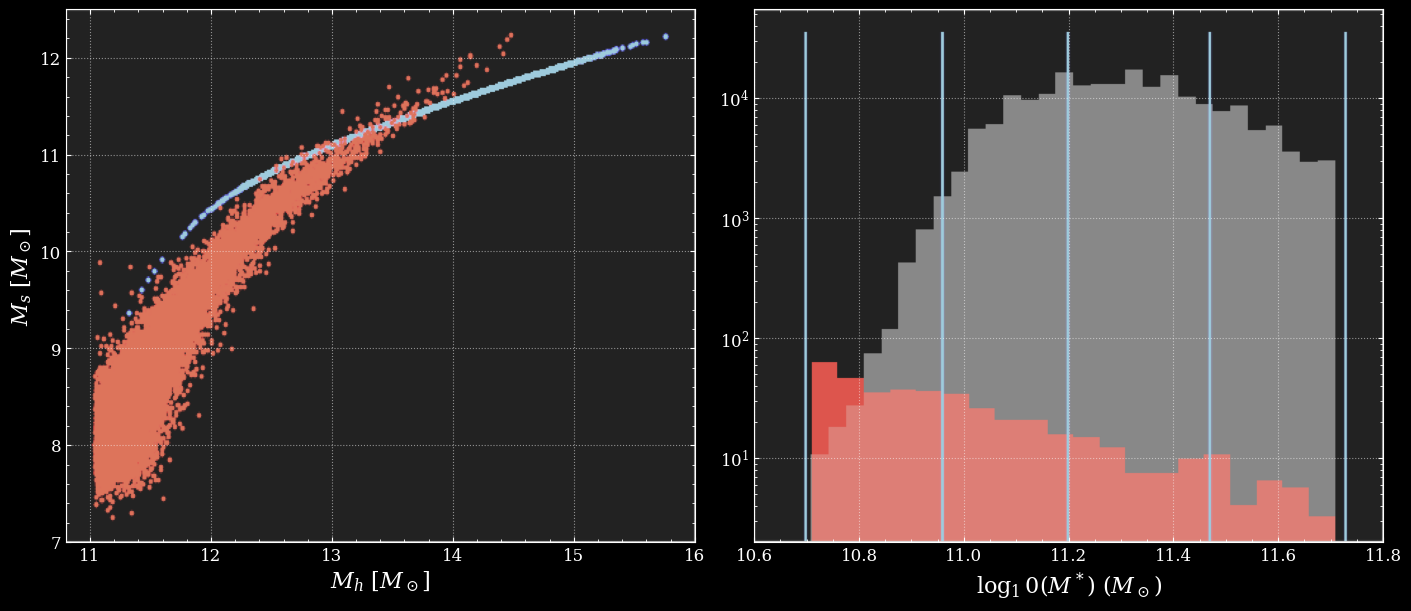

In [3]:
importlib.reload(Moser2021)

fig, axs = Moser2021.Fig3().full()

In [ ]:
importlib.reload(Moser2021)
fig, axs = Moser2021.Fig4row1().full()


hmod = HaloModels.colossus_model(Moser2021.Study().info, PlinMod='eisenstein98')
rs, z = np.geomspace(1e-3, 1e2, 25), 0.55
MoserModel = lambda inps: Moser2021.Moser2021(inps,rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin, **Moser2021.Study().info)

M21 = MoserModel({'match':'matched', 'select':'star', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, np.average(M21.dens(rs, z, b_cen.T[0], units='cgs')()[:, 0, :], weights=p, axis=-1), alpha=0.7, marker='x', c='coral', label=f'ms-red m')
axs[1].scatter(rs, np.average(M21.pres(rs, z, b_cen.T[0], units='cgs')()[:, 0, :], weights=p, axis=-1), alpha=0.7, marker='x', c='coral', label=f'ms-red m')

M21 = MoserModel({'match':'matched', 'select':'star', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, np.average(M21.dens(rs, z, b_cen.T[0], units='cgs')()[:, 0, :], weights=p, axis=-1), alpha=0.7, marker='o', c='coral', label=f'ms-red m 1h')
axs[1].scatter(rs, np.average(M21.pres(rs, z, b_cen.T[0], units='cgs')()[:, 0, :], weights=p, axis=-1), alpha=0.7, marker='o', c='coral', label=f'ms-red m 1h')

# M21 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
# axs[0].scatter(rs, M21.dens(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='w', label=f'ms-tot m, logM={logM_ms_t_m}')

# M21 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
# axs[0].scatter(rs, M21.dens(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='w', label=f'ms-tot m 1h, logM={logM_ms_t_m}')

# M21 = MoserModel({'match':'matched', 'select':'halo', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
# axs[0].scatter(rs, M21.dens(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='magenta', label=f'mh-red m, logM={logM_mh_r_m}')
# axs[1].scatter(rs, M21.pres(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='magenta', label=f'mh-red m, logM={logM_mh_r_m}')

# M21 = MoserModel({'match':'matched', 'select':'halo', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
# axs[0].scatter(rs, M21.dens(rs, z, 12.9, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='magenta', label='mh-red m 1h, logM=12.9')
# axs[1].scatter(rs, M21.pres(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='magenta', label=f'mh-red m 1h, logM={logM_mh_r_m}')

# M21 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
# axs[0].scatter(rs, M21.dens(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='teal', label=f'mh-tot m, logM={logM_mh_t_m}')

# M21 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
# axs[0].scatter(rs, M21.dens(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='teal', label=f'mh-tot m h, logM={logM_mh_t_m}')

# M21 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
# axs[1].scatter(rs, M21.pres(rs, z, logM_ms_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='lime', label=f'ms-red um, logM={logM_ms_r_um}')

# M21 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
# axs[1].scatter(rs, M21.pres(rs, z, logM_ms_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='lime', label=f'ms-red um 1h, logM={logM_ms_r_um}')

# M21 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
# axs[1].scatter(rs, M21.pres(rs, z, logM_mh_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='orange', label=f'mh-red um, logM={logM_mh_r_um}')

# M21 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
# axs[1].scatter(rs, M21.pres(rs, z, logM_mh_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='orange', label=f'mh-red um 1h, logM={logM_mh_r_um}')

axs[0].legend(title='z=0.55', fontsize=10); axs[1].legend(title='z=0.55', fontsize=10)
plt.show()

In [ ]:
importlib.reload(Moser2021)
fig, axs = Moser2021.Fig4row1().full()



hmod = HaloModels.colossus_model(Moser2021.Study().info, PlinMod='eisenstein98')
rs, z = np.geomspace(1e-3, 1e2, 25), 0.55
MoserModel = lambda inps: Moser2021.Moser2021(inps,rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin, **Moser2021.Study().info)

logM_ms_r_m = 13.25
logM_ms_t_m = 13.25
logM_mh_r_m = 13.25
logM_mh_t_m = 13.25

logM_ms_r_um = 12.9
logM_ms_t_um = 12.9
logM_mh_r_um = 12.9
logM_mh_t_um = 12.9

M21 = MoserModel({'match':'matched', 'select':'star', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, M21.dens(rs, z, logM_ms_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='coral', label=f'ms-red m, logM={logM_ms_r_m}')
axs[1].scatter(rs, M21.pres(rs, z, logM_ms_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='coral', label=f'ms-red m, logM={logM_ms_r_m}')

M21 = MoserModel({'match':'matched', 'select':'star', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, M21.dens(rs, z, logM_ms_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='coral', label=f'ms-red m 1h, logM={logM_ms_r_m}')
axs[1].scatter(rs, M21.pres(rs, z, logM_ms_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='coral', label=f'ms-red m 1h, logM={logM_ms_r_m}')

M21 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, M21.dens(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='w', label=f'ms-tot m, logM={logM_ms_t_m}')

M21 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, M21.dens(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='w', label=f'ms-tot m 1h, logM={logM_ms_t_m}')

M21 = MoserModel({'match':'matched', 'select':'halo', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, M21.dens(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='magenta', label=f'mh-red m, logM={logM_mh_r_m}')
axs[1].scatter(rs, M21.pres(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='magenta', label=f'mh-red m, logM={logM_mh_r_m}')

M21 = MoserModel({'match':'matched', 'select':'halo', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, M21.dens(rs, z, 12.9, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='magenta', label='mh-red m 1h, logM=12.9')
axs[1].scatter(rs, M21.pres(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='magenta', label=f'mh-red m 1h, logM={logM_mh_r_m}')

M21 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, M21.dens(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='teal', label=f'mh-tot m, logM={logM_mh_t_m}')

MoseM21r2021 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, M21.dens(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='teal', label=f'mh-tot m h, logM={logM_mh_t_m}')

M21 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
axs[1].scatter(rs, M21.pres(rs, z, logM_ms_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='lime', label=f'ms-red um, logM={logM_ms_r_um}')

M21 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
axs[1].scatter(rs, M21.pres(rs, z, logM_ms_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='lime', label=f'ms-red um 1h, logM={logM_ms_r_um}')

M21 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
axs[1].scatter(rs, M21.pres(rs, z, logM_mh_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='orange', label=f'mh-red um, logM={logM_mh_r_um}')

M21 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
axs[1].scatter(rs, M21.pres(rs, z, logM_mh_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='orange', label=f'mh-red um 1h, logM={logM_mh_r_um}')

axs[0].legend(title='z=0.55', fontsize=10); axs[1].legend(title='z=0.55', fontsize=10)
plt.show()

In [ ]:
importlib.reload(Moser2021)
fig, axs = Moser2021.Fig6col1().full()


hmod = HaloModels.colossus_model(Moser2021.Study().info, PlinMod='eisenstein98')
rs, z = np.geomspace(1e-3, 1e2, 25), 0.55
MoserModel = lambda inps: Moser2021.Moser2021(inps,rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin, **Moser2021.Study().info)

M21 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, M21.dens1h(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], marker='s', c='purple', label=f'mh-tot m, logM={logM_mh_t_m}')
axs[1].scatter(rs, M21.pres1h(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], marker='s', c='purple', label=f'mh-tot m, logM={logM_mh_t_m}')

M21 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, M21.dens1h(rs, z, logM_mh_t_um, units='cgs')()[:, 0, 0], marker='+',c='purple', label=f'mh-tot um, logM={logM_mh_t_um}')
axs[1].scatter(rs, M21.pres1h(rs, z, logM_mh_t_um, units='cgs')()[:, 0, 0], marker='+', c='purple', label=f'mh-tot um, logM={logM_mh_t_um}')

M21 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, M21.dens1h(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], marker='x', c='purple', label=f'mh-tot m 1h, logM={logM_mh_t_m}')
axs[1].scatter(rs, M21.pres1h(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], marker='x', c='purple', label=f'mh-tot m 1h, logM={logM_mh_t_m}')

M21 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, M21.dens1h(rs, z, logM_mh_t_um, units='cgs')()[:, 0, 0], c='purple', label=f'mh-tot um 1h, logM={logM_mh_t_um}')
axs[1].scatter(rs, M21.pres1h(rs, z, logM_mh_t_um, units='cgs')()[:, 0, 0], c='purple', label=f'mh-tot um 1h, logM={logM_mh_t_um}')

M21 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, M21.dens1h(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], marker='s', c='coral', label=f'mh-tot m, logM={logM_ms_t_m}')
axs[1].scatter(rs, M21.pres1h(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], marker='s', c='coral', label=f'mh-tot m, logM={logM_ms_t_m}')

M21 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, M21.dens1h(rs, z, logM_ms_t_um, units='cgs')()[:, 0, 0], marker='+',c='coral', label=f'mh-tot um, logM={logM_ms_t_um}')
axs[1].scatter(rs, M21.pres1h(rs, z, logM_ms_t_um, units='cgs')()[:, 0, 0], marker='+', c='coral', label=f'mh-tot um, logM={logM_ms_t_um}')

M21 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, M21.dens1h(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], marker='x', c='coral', label=f'ms-tot m 1h, logM={logM_ms_t_m}')
axs[1].scatter(rs, M21.pres1h(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], marker='x', c='coral', label=f'ms-tot m 1h, logM={logM_ms_t_m}')

M21 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, M21.dens(rs, z, logM_ms_t_um, units='cgs')()[:, 0, 0], c='coral', label=f'ms-tot um 1h, logM={logM_ms_t_um}')
axs[1].scatter(rs, M21.pres(rs, z, logM_ms_t_um, units='cgs')()[:, 0, 0], c='coral', label=f'ms-tot um 1h, logM={logM_ms_t_um}')


axs[0].legend(title='z=0.55', fontsize=10); axs[1].legend(title='z=0.55', fontsize=10)
plt.show()